# 02c — CoT Stability Analysis (Same Prompt, Multiple Generations)

**Purpose:** Measure how stable the CoT LLM method is when given the same prompt
multiple times. Since CLAP and SBERT are deterministic (same embeddings = same scores),
only the CoT LLM method can produce different results across runs.

For each of the 8 `TEST_PROMPTS`, we run the CoT feature selection N times and measure:
1. **Feature selection overlap** — Jaccard similarity across runs
2. **Range consistency** — how much min/max predictions vary for the same feature
3. **Weight stability** — variance of assigned weights

**Cost:** This notebook makes LLM API calls (8 prompts x N runs).

**Prerequisites:** Run `02a_data_feature_prep.ipynb` first.

In [6]:
# --- Shared Setup ---
import sys
sys.path.insert(0, '..')

import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations

warnings.filterwarnings('ignore', category=FutureWarning)

try:
    from google import genai
    from google.genai import types as genai_types
    GEMINI_AVAILABLE = True
except ImportError:
    GEMINI_AVAILABLE = False
    print('google-genai SDK not available')
    
from atdj.config import PROCESSED_DIR, DATA_DIR

FEATURES_DIR = Path(PROCESSED_DIR) / 'features_exp'
df_merged = pd.read_pickle(FEATURES_DIR / 'df_merged.pkl')
print(f'Loaded df_merged: {df_merged.shape}')

import pickle
with open(FEATURES_DIR / 'feature_catalog.pkl', 'rb') as f:
    FEATURE_CATALOG = pickle.load(f)

with open(FEATURES_DIR / 'feature_prompt.txt', encoding='utf-8') as f:
    FEATURE_PROMPT = f.read()

print(f'Feature catalog loaded: {len(FEATURE_CATALOG)} groups')

Loaded df_merged: (184, 213)
Feature catalog loaded: 15 groups


In [3]:
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
GEMINI_MODEL = os.getenv('GEMINI_MODEL', 'gemini-2.0-flash')
LLM_READY = GEMINI_API_KEY is not None
if LLM_READY:
    print(f'LLM ready: model={GEMINI_MODEL}')
else:
    print('LLM not ready — set GEMINI_API_KEY')


def llm_chat(client, system: str, user_message: str, max_tokens: int = 2000) -> str:
    import random
    max_retries = 8
    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=user_message,
                config=genai_types.GenerateContentConfig(
                    system_instruction=system if system else None,
                    max_output_tokens=max_tokens,
                ),
            )
            return response.text.strip()
        except Exception as e:
            if ('429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e)) and attempt < max_retries - 1:
                wait = min(30 * (2 ** attempt), 300) + random.uniform(0, 10)
                print(f'  Rate limited, waiting {wait:.0f}s (attempt {attempt+1}/{max_retries})...')
                time.sleep(wait)
            else:
                raise

LLM ready: model=gemini-2.0-flash


In [4]:
# --- CoT prompts (same as 02b_method2) ---
COT_SYSTEM_PROMPT = """You are an expert Argentine Tango DJ and audio engineer.
You help match text descriptions of desired music to songs using audio features.

When given a text prompt and a list of available audio features with their observed ranges,
you must select the most relevant features and predict target value ranges that would
match the described music."""

COT_USER_TEMPLATE = """Given a user's text prompt describing desired tango music, select the most
relevant audio features and specify target ranges for song matching.

## Available Features (with observed ranges in our 100-song catalog):
{feature_descriptions}

## User Prompt: \"{prompt}\"

## Instructions:
Think step by step:
1. What musical qualities does this prompt describe?
2. Which features from the list above best capture those qualities? Select 5-10 features.
3. For each selected feature, what value range would match the prompt? Use the observed ranges as guidance.
4. Validate your reasoning: does this combination of features and ranges make musical sense together?
   If not, refine your selections.

## Response Format:
Respond ONLY with valid JSON (no markdown, no code blocks):
{{
  "reasoning": "Brief explanation of your musical interpretation and feature choices",
  "selected_features": {{
    "feature_name": {{
      "min": <float>,
      "max": <float>,
      "direction": "higher_better" | "lower_better" | "range",
      "weight": <float 0-1, importance of this feature>
    }}
  }},
  "validation": "Brief validation that this combination makes sense"
}}"""


def cot_select_and_range(prompt: str, feature_desc: str, client) -> dict:
    """Ask LLM to select features and predict ranges via CoT."""
    user_message = COT_USER_TEMPLATE.format(
        feature_descriptions=feature_desc,
        prompt=prompt
    )
    response_text = llm_chat(client, COT_SYSTEM_PROMPT, user_message, max_tokens=2000)
    if response_text.startswith('```'):
        response_text = response_text.split('```')[1]
        if response_text.startswith('json'):
            response_text = response_text[4:]
    try:
        return json.loads(response_text)
    except json.JSONDecodeError as e:
        print(f'  WARNING: Failed to parse LLM response as JSON: {e}')
        return {'selected_features': {}, 'reasoning': 'Parse error'}


TEST_PROMPTS = [
    'energetic tango with strong rhythm for experienced dancers',
    'melancholic and slow, perfect for a late-night vals',
    'bright and cheerful milonga with clear melody',
    'dramatic tango with heavy bandoneon and dark mood',
    'smooth and relaxed, good for warming up the floor',
    'classic golden-age tango from the 40s, warm and nostalgic',
    'a lively vals from the 50s with a strong orchestra',
    'need a cortina — something upbeat and non-tango to reset the floor',
]

print(f'CoT functions defined. {len(TEST_PROMPTS)} test prompts.')

CoT functions defined. 8 test prompts.


In [7]:
# --- Run each prompt N times ---
N_RUNS = 5  # number of generations per prompt

if LLM_READY:
    client = genai.Client(api_key=GEMINI_API_KEY)
    # multi_runs[prompt_idx] = list of N dicts with 'selected_features'
    multi_runs = {i: [] for i in range(len(TEST_PROMPTS))}

    total_calls = len(TEST_PROMPTS) * N_RUNS
    call_count = 0
    t_start = time.time()

    for run in range(N_RUNS):
        print(f'\n--- Run {run+1}/{N_RUNS} ---')
        for i, prompt in enumerate(TEST_PROMPTS):
            call_count += 1
            result = cot_select_and_range(prompt, FEATURE_PROMPT, client)
            features = list(result.get('selected_features', {}).keys())
            multi_runs[i].append(result)
            print(f'  [{call_count}/{total_calls}] P{i+1}: {len(features)} features')
            time.sleep(10)  # pace requests to avoid Vertex AI 429s

    elapsed = time.time() - t_start
    print(f'\nDone: {call_count} calls in {elapsed:.0f}s ({elapsed/call_count:.1f}s per call)')
else:
    print('LLM not ready — cannot run stability analysis')
    multi_runs = {}


--- Run 1/5 ---
  [1/40] P1: 7 features
  [2/40] P2: 5 features
  [3/40] P3: 7 features
  [4/40] P4: 7 features
  [5/40] P5: 7 features
  [6/40] P6: 7 features
  [7/40] P7: 6 features
  [8/40] P8: 7 features

--- Run 2/5 ---
  [9/40] P1: 6 features
  [10/40] P2: 6 features
  Rate limited, waiting 30s (attempt 1/8)...
  [11/40] P3: 7 features
  [12/40] P4: 7 features
  Rate limited, waiting 34s (attempt 1/8)...
  Rate limited, waiting 62s (attempt 2/8)...
  [13/40] P5: 9 features
  [14/40] P6: 8 features
  Rate limited, waiting 33s (attempt 1/8)...
  [15/40] P7: 7 features
  [16/40] P8: 7 features

--- Run 3/5 ---
  [17/40] P1: 7 features
  [18/40] P2: 6 features
  [19/40] P3: 7 features
  [20/40] P4: 7 features
  [21/40] P5: 0 features
  Rate limited, waiting 33s (attempt 1/8)...
  Rate limited, waiting 63s (attempt 2/8)...
  Rate limited, waiting 121s (attempt 3/8)...
  [22/40] P6: 7 features
  [23/40] P7: 9 features
  [24/40] P8: 7 features

--- Run 4/5 ---
  Rate limited, waiting 3

## 1. Feature Selection Overlap (Jaccard Similarity)

For each prompt, how much do the selected feature sets overlap across N runs?

Feature selection overlap (Jaccard) across 5 runs per prompt:

P1: "energetic tango with strong rhythm for experienced..."
  Jaccard: 0.621 (min=0.444, max=0.857)
  Always selected (4): ['average_loudness', 'bpm', 'onset_rate', 'tempogram_global_mean']
  Sometimes selected (7): ['danceability', 'dynamic_complexity', 'mfcc_1_std', 'mood_happy', 'percussive_energy', 'spectral_complexity_mean', 'tempogram_max_bin_strength']

P2: "melancholic and slow, perfect for a late-night val..."
  Jaccard: 0.380 (min=0.222, max=0.714)
  Always selected (2): ['bpm', 'mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding']
  Sometimes selected (11): ['average_loudness', 'chroma_1_std', 'duration', 'key_strength', 'mood_acoustic', 'mood_happy', 'mood_relaxed', 'onset_rate', 'rms_mean', 'spectral_complexity_mean', 'style']

P3: "bright and cheerful milonga with clear melody..."
  Jaccard: 0.528 (min=0.400, max=0.857)
  Always selected (3): ['bpm', 'mirex_mood_rollicking_cheerful_fun_sweet_am

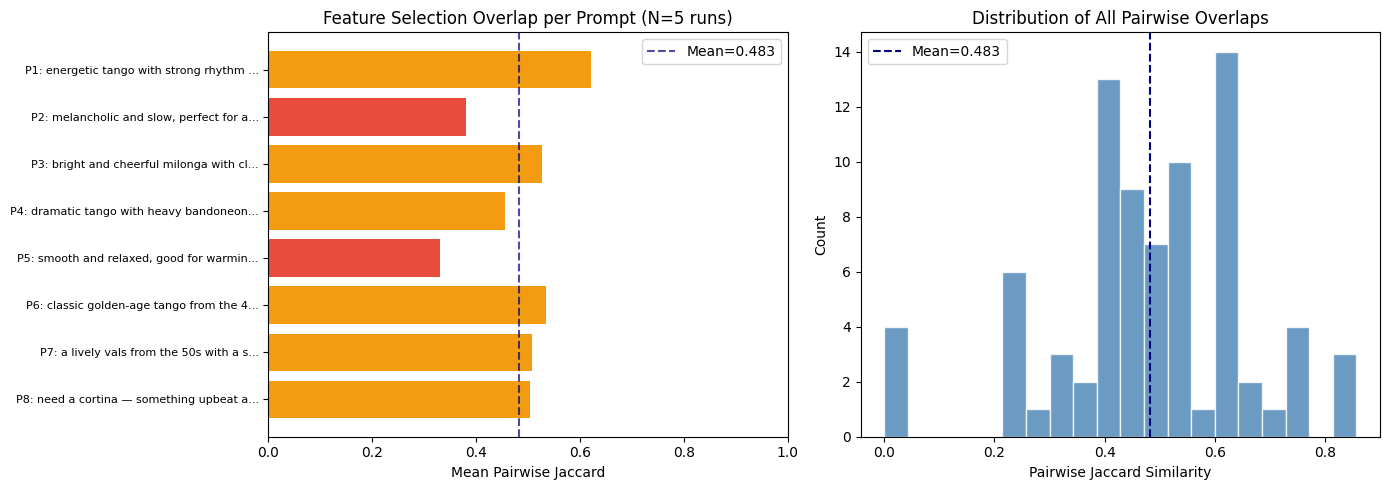

In [8]:
def jaccard(set_a, set_b):
    if not set_a and not set_b:
        return 1.0
    union = set_a | set_b
    return len(set_a & set_b) / len(union) if union else 0.0


if multi_runs:
    prompt_jaccards = []  # per-prompt average Jaccard
    all_pair_jaccards = []  # all pairwise Jaccards

    print(f'Feature selection overlap (Jaccard) across {N_RUNS} runs per prompt:\n')
    for i, prompt in enumerate(TEST_PROMPTS):
        runs = multi_runs[i]
        feature_sets = [set(r.get('selected_features', {}).keys()) for r in runs]

        # Pairwise Jaccard
        pair_scores = []
        for a, b in combinations(range(len(feature_sets)), 2):
            j = jaccard(feature_sets[a], feature_sets[b])
            pair_scores.append(j)
            all_pair_jaccards.append(j)

        mean_j = np.mean(pair_scores) if pair_scores else 0
        prompt_jaccards.append(mean_j)

        # Which features appear in all runs vs some runs?
        all_feats = set().union(*feature_sets)
        always = [f for f in all_feats if all(f in fs for fs in feature_sets)]
        sometimes = [f for f in all_feats if not all(f in fs for fs in feature_sets)]

        print(f'P{i+1}: "{prompt[:50]}..."')
        print(f'  Jaccard: {mean_j:.3f} (min={min(pair_scores):.3f}, max={max(pair_scores):.3f})')
        print(f'  Always selected ({len(always)}): {sorted(always)}')
        print(f'  Sometimes selected ({len(sometimes)}): {sorted(sometimes)}')
        print()

    # Summary bar chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Per-prompt Jaccard
    colors = ['#2ecc71' if j > 0.7 else '#f39c12' if j > 0.4 else '#e74c3c' for j in prompt_jaccards]
    ax1.barh(range(len(TEST_PROMPTS)), prompt_jaccards, color=colors)
    ax1.set_yticks(range(len(TEST_PROMPTS)))
    ax1.set_yticklabels([f'P{i+1}: {p[:35]}...' for i, p in enumerate(TEST_PROMPTS)], fontsize=8)
    ax1.set_xlabel('Mean Pairwise Jaccard')
    ax1.set_title(f'Feature Selection Overlap per Prompt (N={N_RUNS} runs)')
    ax1.set_xlim(0, 1)
    ax1.axvline(x=np.mean(prompt_jaccards), color='navy', linestyle='--', alpha=0.7,
                label=f'Mean={np.mean(prompt_jaccards):.3f}')
    ax1.legend()
    ax1.invert_yaxis()

    # Distribution of all pairwise Jaccards
    ax2.hist(all_pair_jaccards, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax2.axvline(x=np.mean(all_pair_jaccards), color='navy', linestyle='--',
                label=f'Mean={np.mean(all_pair_jaccards):.3f}')
    ax2.set_xlabel('Pairwise Jaccard Similarity')
    ax2.set_ylabel('Count')
    ax2.set_title('Distribution of All Pairwise Overlaps')
    ax2.legend()

    plt.tight_layout()
    plt.show()

### Insight — Feature Selection Overlap

- **Mean Jaccard = 0.483** — the LLM selects roughly half-overlapping feature sets across runs, confirming non-trivial stochasticity in feature selection.
- **Concrete prompts are more stable.** P1 ("energetic tango with strong rhythm") achieves the highest overlap (0.621) — its musical intent maps unambiguously to tempo/loudness features. P5 ("smooth and relaxed") is the least stable (0.330) with zero features selected in all 5 runs, suggesting vague prompts leave more room for the model to wander.
- **Core features emerge despite variance.** `bpm` appears in the "always selected" set for 6/8 prompts; `average_loudness` and `onset_rate` are similarly reliable anchors. The instability concentrates in secondary features (e.g., `mfcc_1_std`, `spectral_contrast_7_mean`).
- **One JSON parse failure** (P5 run 3) produced 0 features, dragging P5's Jaccard down — a reminder that structured-output reliability is itself a stability concern.

## 2. Range Consistency per Feature

For features that are selected across multiple runs of the same prompt,
how much do the predicted min/max ranges vary?

Range consistency by feature (lower cv = more consistent):
                                                                    mean_width_cv  mean_midpoint_std  total_appearances
feature                                                                                                                
mood_acoustic                                                               0.000              0.000                 11
style                                                                       0.000              0.250                  5
tempogram_max_bin_strength                                                  0.000              0.000                  2
jamendo_dance                                                               0.000              0.000                  3
duration                                                                    0.025              0.736                  3
spectral_complexity_mean                                                    0.041              0.357 

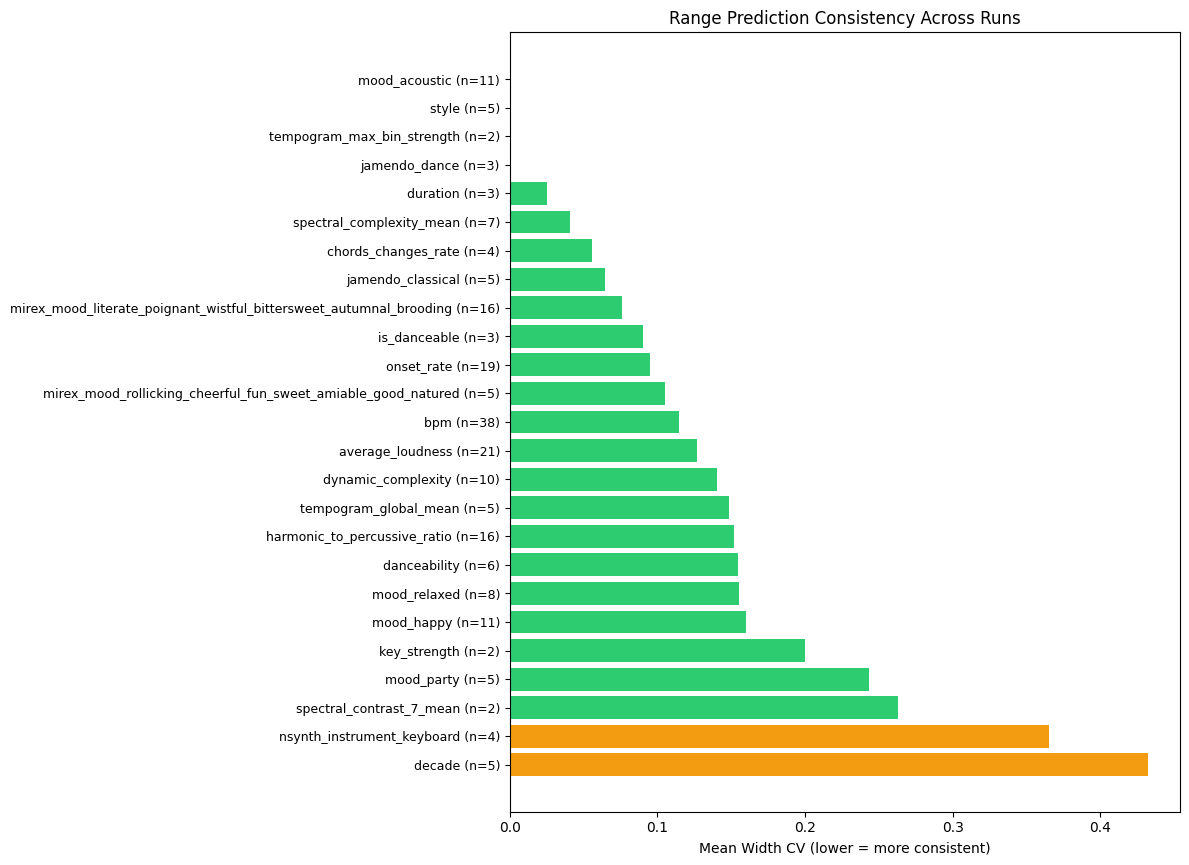

In [9]:
if multi_runs:
    # For each prompt, collect ranges per feature across runs
    range_consistency = []  # list of {prompt_idx, feature, range_cv, n_appearances}

    for i in range(len(TEST_PROMPTS)):
        runs = multi_runs[i]
        # Collect per-feature across runs
        feat_ranges = {}  # feature -> list of (min, max)
        for r in runs:
            for fname, spec in r.get('selected_features', {}).items():
                lo, hi = spec.get('min'), spec.get('max')
                if lo is not None and hi is not None:
                    try:
                        lo, hi = float(lo), float(hi)
                    except (ValueError, TypeError):
                        continue
                    feat_ranges.setdefault(fname, []).append((lo, hi))

        for fname, ranges in feat_ranges.items():
            if len(ranges) >= 2:
                widths = [hi - lo for lo, hi in ranges]
                mids = [(lo + hi) / 2 for lo, hi in ranges]
                range_consistency.append({
                    'prompt_idx': i,
                    'feature': fname,
                    'n_appearances': len(ranges),
                    'width_cv': np.std(widths) / np.mean(widths) if np.mean(widths) > 0 else 0,
                    'midpoint_std': np.std(mids),
                    'midpoint_mean': np.mean(mids),
                })

    rc_df = pd.DataFrame(range_consistency)
    if len(rc_df) > 0:
        # Aggregate by feature (across all prompts)
        feat_agg = rc_df.groupby('feature').agg(
            mean_width_cv=('width_cv', 'mean'),
            mean_midpoint_std=('midpoint_std', 'mean'),
            total_appearances=('n_appearances', 'sum'),
        ).sort_values('mean_width_cv')

        print('Range consistency by feature (lower cv = more consistent):')
        print(feat_agg.to_string(float_format='%.3f'))

        # Plot
        fig, ax = plt.subplots(figsize=(12, max(5, len(feat_agg) * 0.35)))
        colors = ['#2ecc71' if cv < 0.3 else '#f39c12' if cv < 0.6 else '#e74c3c'
                  for cv in feat_agg['mean_width_cv']]
        ax.barh(range(len(feat_agg)), feat_agg['mean_width_cv'], color=colors)
        ax.set_yticks(range(len(feat_agg)))
        ax.set_yticklabels([f'{f} (n={int(n)})' for f, n in
                            zip(feat_agg.index, feat_agg['total_appearances'])], fontsize=9)
        ax.set_xlabel('Mean Width CV (lower = more consistent)')
        ax.set_title('Range Prediction Consistency Across Runs')
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print('Not enough data for range consistency analysis')

### Insight — Range Consistency

- **Ranges are surprisingly stable** (mean width CV = 0.113). Once the model selects a feature, it predicts similar min/max bounds across runs — the variance problem is mostly *which* features get picked, not *how* they are parameterized.
- **Binary/categorical features are perfectly consistent** — `mood_acoustic`, `style`, `jamendo_dance` all show CV = 0.000 because their value domains are narrow and unambiguous.
- **`decade` is the least consistent** (CV = 0.432, midpoint std = 777.6). The model struggles to map "golden-age" or "50s" to a precise numeric range, sometimes outputting raw year values vs. decade bins — a schema ambiguity worth addressing in the feature prompt.
- **High-frequency features** (`bpm`, `onset_rate`, `average_loudness` with 19-38 appearances) maintain low CV (0.10-0.13), reinforcing that the model has stable internal calibration for core audio features.

## 3. Weight Stability

For features selected across multiple runs of the same prompt,
how much does the assigned weight vary?

Weight stability by feature (lower std = more consistent):
                                                                    mean_weight  mean_weight_std  total_n
feature                                                                                                  
decade                                                                    1.000            0.000       10
spectral_contrast_7_mean                                                  0.500            0.000        2
style                                                                     0.992            0.012       15
jamendo_classical                                                         0.367            0.024        5
chords_changes_rate                                                       0.475            0.025        4
onset_rate                                                                0.651            0.027       19
tempogram_global_mean                                                     0.560            0.

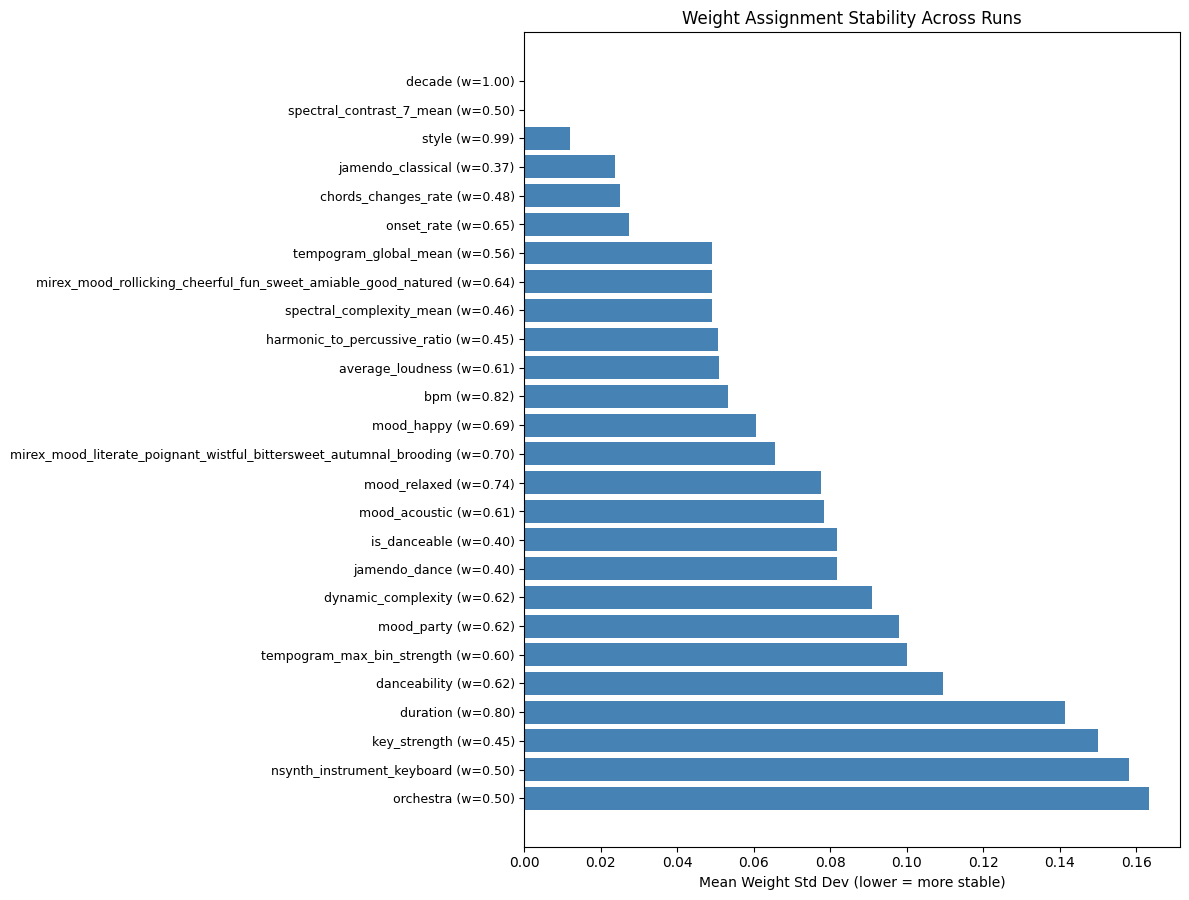

In [10]:
if multi_runs:
    weight_records = []  # {prompt_idx, feature, weights, std, mean}

    for i in range(len(TEST_PROMPTS)):
        runs = multi_runs[i]
        feat_weights = {}  # feature -> list of weights
        for r in runs:
            for fname, spec in r.get('selected_features', {}).items():
                w = spec.get('weight')
                if w is not None:
                    try:
                        feat_weights.setdefault(fname, []).append(float(w))
                    except (ValueError, TypeError):
                        pass

        for fname, ws in feat_weights.items():
            if len(ws) >= 2:
                weight_records.append({
                    'prompt_idx': i,
                    'feature': fname,
                    'n': len(ws),
                    'weight_mean': np.mean(ws),
                    'weight_std': np.std(ws),
                })

    w_df = pd.DataFrame(weight_records)
    if len(w_df) > 0:
        feat_w_agg = w_df.groupby('feature').agg(
            mean_weight=('weight_mean', 'mean'),
            mean_weight_std=('weight_std', 'mean'),
            total_n=('n', 'sum'),
        ).sort_values('mean_weight_std')

        print('Weight stability by feature (lower std = more consistent):')
        print(feat_w_agg.to_string(float_format='%.3f'))

        fig, ax = plt.subplots(figsize=(12, max(5, len(feat_w_agg) * 0.35)))
        ax.barh(range(len(feat_w_agg)), feat_w_agg['mean_weight_std'], color='steelblue')
        ax.set_yticks(range(len(feat_w_agg)))
        ax.set_yticklabels([f'{f} (w={m:.2f})' for f, m in
                            zip(feat_w_agg.index, feat_w_agg['mean_weight'])], fontsize=9)
        ax.set_xlabel('Mean Weight Std Dev (lower = more stable)')
        ax.set_title('Weight Assignment Stability Across Runs')
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print('Not enough data for weight stability analysis')

### Insight — Weight Stability

- **Weights are the most stable dimension** (mean std = 0.059). The model assigns nearly identical importance scores across runs, suggesting strong internal priors about feature relevance hierarchies.
- **`decade` and `style` are always maxed out** (weight ~1.0, std ~0.0) — when the prompt mentions a specific era or genre, the model treats it as a hard constraint rather than a soft preference. This is musically sensible.
- **`bpm` holds steady at 0.82** — consistently the highest-weighted continuous feature, confirming tempo as the dominant matching signal in the model's reasoning.
- **Tail features show more weight variance** — `key_strength` (std=0.15), `nsynth_instrument_keyboard` (std=0.16), `orchestra` (std=0.16) fluctuate the most, likely because the model is uncertain about their relevance to any given prompt.

## 4. Summary

In [11]:
if multi_runs:
    print(f'=== CoT Stability Summary ({N_RUNS} runs x {len(TEST_PROMPTS)} prompts) ===')
    print(f'\nFeature Selection Overlap:')
    print(f'  Mean Jaccard: {np.mean(prompt_jaccards):.3f}')
    print(f'  Most stable prompt:  P{np.argmax(prompt_jaccards)+1} ({max(prompt_jaccards):.3f})')
    print(f'  Least stable prompt: P{np.argmin(prompt_jaccards)+1} ({min(prompt_jaccards):.3f})')

    if len(rc_df) > 0:
        print(f'\nRange Consistency:')
        print(f'  Mean width CV: {rc_df["width_cv"].mean():.3f}')
        most_stable = feat_agg['mean_width_cv'].idxmin()
        least_stable = feat_agg['mean_width_cv'].idxmax()
        print(f'  Most consistent feature:  {most_stable} (cv={feat_agg.loc[most_stable, "mean_width_cv"]:.3f})')
        print(f'  Least consistent feature: {least_stable} (cv={feat_agg.loc[least_stable, "mean_width_cv"]:.3f})')

    if len(w_df) > 0:
        print(f'\nWeight Stability:')
        print(f'  Mean weight std: {w_df["weight_std"].mean():.3f}')

    # Save multi-run data for potential reuse
    save_path = FEATURES_DIR / 'cot_stability_runs.json'
    save_data = {
        'n_runs': N_RUNS,
        'model': GEMINI_MODEL,
        'prompts': TEST_PROMPTS,
        'runs': {str(i): runs for i, runs in multi_runs.items()},
    }

    def _jsonify(obj):
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, dict):
            return {k: _jsonify(v) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)):
            return [_jsonify(v) for v in obj]
        return obj

    with open(save_path, 'w', encoding='utf-8') as f:
        json.dump(_jsonify(save_data), f, indent=2)
    print(f'\nSaved raw run data to {save_path.name}')

=== CoT Stability Summary (5 runs x 8 prompts) ===

Feature Selection Overlap:
  Mean Jaccard: 0.483
  Most stable prompt:  P1 (0.621)
  Least stable prompt: P5 (0.330)

Range Consistency:
  Mean width CV: 0.113
  Most consistent feature:  mood_acoustic (cv=0.000)
  Least consistent feature: decade (cv=0.432)

Weight Stability:
  Mean weight std: 0.059

Saved raw run data to cot_stability_runs.json


### Insight — Overall Stability Assessment

**The CoT method is semi-stable: ranges and weights are reliable, but feature selection is not.**

| Dimension | Stability | Implication |
|-----------|-----------|-------------|
| Feature selection | Moderate (Jaccard 0.48) | Different runs may retrieve partially different song sets |
| Range prediction | High (CV 0.11) | Once a feature is chosen, its target range is consistent |
| Weight assignment | High (std 0.06) | Feature importance ranking is nearly deterministic |

**Practical takeaway for AT-DJ:** A single CoT call is sufficient for range/weight estimation, but feature selection would benefit from an **ensemble strategy** — run the CoT 3 times and keep features selected in >=2/3 of runs. This would stabilize the feature set while preserving the model's strong range calibration. Alternatively, a fixed "core feature set" (bpm, loudness, onset_rate) plus LLM-selected supplementary features could combine stability with flexibility.